<a href="https://colab.research.google.com/github/Riz2693/Dicoding-Submission-FDL/blob/main/Analisis%20Sentimen/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Data Preparation**
- Muhammad Faris Akbar
- Dicoding Analisis Sentimen (Fundamental Deep Learning)

**Load package dan library**

In [54]:
!pip install gensim

In [55]:
import re
import kagglehub
import gensim
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample, class_weight

from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, GlobalMaxPool1D, GlobalAvgPool1D, concatenate, Input, LayerNormalization, SimpleRNN
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

In [56]:
path = kagglehub.dataset_download("bhimantoros/pretrained-word2vec-indonesia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pretrained-word2vec-indonesia' dataset.
Path to dataset files: /kaggle/input/pretrained-word2vec-indonesia


In [57]:
fix_path = os.path.join(path, "wiki.id.case.model")
print("Path to model file:", fix_path)

Path to model file: /kaggle/input/pretrained-word2vec-indonesia/wiki.id.case.model


**Load dataset sentimen**

In [58]:
df = pd.read_csv('https://raw.githubusercontent.com/Riz2693/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore.csv')

In [59]:
df.head()

,content,score,soft_clean_content,sentiment_label,confidence_score
0,"pesanan banyak yg stuck, ujung2nya gak nyampe....",1,"pesanan banyak yg stuck, gak nyampe. parah pel...",Negatif,0.931733
1,Belanja di Shopee pelayanannya lebih meningkat...,5,Belanja di Shopee pelayanannya lebih meningkat...,Positif,0.970610
2,Pelayanan shopee makin hari makin kacau. CS g ...,1,Pelayanan shopee makin hari makin kacau. CS g ...,Negatif,0.997844
3,pengiriman tidak sesua terus,1,pengiriman tidak sesua terus,Negatif,0.993856
4,kenapa pesanan ku belum sampai ke tempat ku kak,5,kenapa pesanan ku belum sampai ke tempat ku kak,Negatif,0.985725


In [60]:
df.rename(columns={'sentiment_label': 'label'}, inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60931 entries, 0 to 60930
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   content             60931 non-null  object 
 1   score               60931 non-null  int64  
 2   soft_clean_content  60928 non-null  object 
 3   label               60931 non-null  object 
 4   confidence_score    60931 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.3+ MB


In [62]:
df.describe(include='all')

,content,score,soft_clean_content,label,confidence_score
count,60931,60931.000000,60928,60931,60931.000000
unique,60330,NaN,59959,3,NaN
top,bagus,NaN,👍👍,Positif,NaN
freq,5,NaN,14,30609,NaN
mean,NaN,3.714480,NaN,NaN,0.926156
std,NaN,1.728692,NaN,NaN,0.131551
min,NaN,1.000000,NaN,NaN,0.339691
25%,NaN,2.000000,NaN,NaN,0.932846
50%,NaN,5.000000,NaN,NaN,0.989890
75%,NaN,5.000000,NaN,NaN,0.996892


**Load dataset tambahan**

In [63]:
# df_tambahan_netral = pd.read_csv('https://raw.githubusercontent.com/ArmFriiz/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore_netral.csv')

In [64]:
# df_tambahan_netral.info()

In [65]:
# df_tambahan_negatif = pd.read_csv('https://raw.githubusercontent.com/ArmFriiz/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore_negatif.csv')

In [66]:
# df_tambahan_negatif.info()

**Gabungkan dataset utama dan tambahan**

In [67]:
# df = pd.concat([main_df, df_tambahan_netral, df_tambahan_negatif]).reset_index(drop=True)

**Drop column score dam confidence score karena hanya digunakan untuk labelling awal saja**

In [68]:
df.drop(columns=['score', 'confidence_score'], inplace=True)

In [69]:
df.columns

Index(['content', 'soft_clean_content', 'label'], dtype='object')

**Cek ulang kondisi data**

In [70]:
df.isna().sum()

,0
content,0
soft_clean_content,3
label,0


In [71]:
df[df.isna().any(axis=1)]

,content,soft_clean_content,label
1081,0baik,NaN,Netral
29077,0ke,NaN,Netral
60436,9or,NaN,Netral


In [72]:
df.dropna(inplace=True)

In [73]:
df.duplicated().sum()

np.int64(601)

In [74]:
df.drop_duplicates(inplace=True)

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.head(5)

,content,soft_clean_content,label
0,"pesanan banyak yg stuck, ujung2nya gak nyampe....","pesanan banyak yg stuck, gak nyampe. parah pel...",Negatif
1,Belanja di Shopee pelayanannya lebih meningkat...,Belanja di Shopee pelayanannya lebih meningkat...,Positif
2,Pelayanan shopee makin hari makin kacau. CS g ...,Pelayanan shopee makin hari makin kacau. CS g ...,Negatif
3,pengiriman tidak sesua terus,pengiriman tidak sesua terus,Negatif
4,kenapa pesanan ku belum sampai ke tempat ku kak,kenapa pesanan ku belum sampai ke tempat ku kak,Negatif


In [77]:
df.describe(include='all')

,content,soft_clean_content,label
count,60327,60327,60327
unique,60327,59959,3
top,"suka belanja di shopee, simple dan sering dpt ...",goodd,Positif
freq,1,10,30282


**Load model normalisasi kata untuk perbaikan kata slank atau typo**

In [78]:
normalization_df = pd.read_csv('https://raw.githubusercontent.com/nasalsabila/kamus-alay/refs/heads/master/colloquial-indonesian-lexicon.csv')

In [79]:
normalization_df.head()

,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0


In [80]:
normalization_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15006 entries, 0 to 15005
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   slang          15006 non-null  object
 1   formal         15006 non-null  object
 2   In-dictionary  15006 non-null  int64 
 3   context        15006 non-null  object
 4   category1      15006 non-null  object
 5   category2      15006 non-null  object
 6   category3      15006 non-null  object
dtypes: int64(1), object(6)
memory usage: 820.8+ KB


In [81]:
normalization_dict = dict(zip(normalization_df['slang'], normalization_df['formal']))

In [82]:
normalization_dict

{'woww': 'wow',
 'aminn': 'amin',
 'met': 'selamat',
 'netaas': 'menetas',
 'keberpa': 'keberapa',
 'eeeehhhh': 'eh',
 'kata2nyaaa': 'kata-katanya',
 'hallo': 'halo',
 'kaka': 'kakak',
 'ka': 'kak',
 'daah': 'dah',
 'aaaaahhhh': 'ah',
 'yaa': 'ya',
 'smga': 'semoga',
 'slalu': 'selalu',
 'amiin': 'amin',
 'kk': 'kakak',
 'trus': 'terus',
 'sii': 'sih',
 'nyenengin': 'menyenangkan',
 'bgt': 'banget',
 'gemess': 'gemas',
 'akuuu': 'aku',
 'jgn': 'jangan',
 'udah': 'sudah',
 'gitu': 'begitu',
 'aja': 'saja',
 'gemesiin': 'menggemaskan',
 'menyenangkn': 'menyenangkan',
 'rb': 'ribu',
 'akau': 'aku',
 'saranin': 'menyarankan',
 'nemuin': 'menemukan',
 'yah': 'ya',
 'mnis2nya': 'manis-manisnya',
 'gtu': 'begitu',
 'tu': 'itu',
 'idolaa': 'idola',
 'bangett': 'banget',
 'kaakk': 'kak',
 'baaiikkk': 'baik',
 'telaatt': 'telat',
 'kaak': 'kak',
 'yg': 'yang',
 'lg': 'lagi',
 'skarang': 'sekarang',
 'sempet': 'sempat',
 'karna': 'karena',
 'ngga': 'enggak',
 'mantep': 'mantap',
 'loohhh': 'loh',

### **Preprocessing Data**

**Cleaning data (Case folding, Punctuation, Slankword atau typo)**

In [83]:
def cleaning_text(text, normalization_dict):
  text = text.lower() # Ubah teks menjadi huruf kecil

  words = text.split()
  words = [normalization_dict.get(word, word) for word in words]
  text = ' '.join(words)

  text = ''.join([char for char in text if char.isalpha() or char.isspace()])
  text = ' '.join(text.split()) # Bersihkan spasi berlebih di tengah dan di ujung
  return text

In [84]:
df['clean_content'] = df['soft_clean_content'].apply(cleaning_text, normalization_dict=normalization_dict)

In [85]:
df.head()

,content,soft_clean_content,label,clean_content
0,"pesanan banyak yg stuck, ujung2nya gak nyampe....","pesanan banyak yg stuck, gak nyampe. parah pel...",Negatif,pesanan banyak yang stuck enggak nyampe parah ...
1,Belanja di Shopee pelayanannya lebih meningkat...,Belanja di Shopee pelayanannya lebih meningkat...,Positif,belanja di shopee pelayanannya lebih meningkat...
2,Pelayanan shopee makin hari makin kacau. CS g ...,Pelayanan shopee makin hari makin kacau. CS g ...,Negatif,pelayanan shopee makin hari makin kacau cs eng...
3,pengiriman tidak sesua terus,pengiriman tidak sesua terus,Negatif,pengiriman tidak sesua terus
4,kenapa pesanan ku belum sampai ke tempat ku kak,kenapa pesanan ku belum sampai ke tempat ku kak,Negatif,kenapa pesanan ku belum sampai ke tempat ku kak


**Cek jumlah label data dan kata yang terkandung pada data sebelum resample**

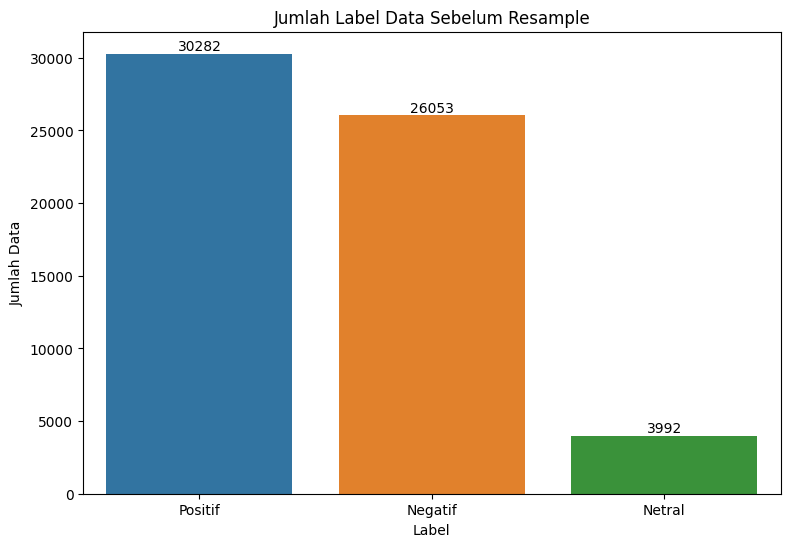

In [86]:
plt.figure(figsize=(9, 6))
sns.barplot(x=df['label'].value_counts().index, y=df['label'].value_counts().values, hue=df['label'].value_counts().index)
plt.title('Jumlah Label Data Sebelum Resample')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.show()

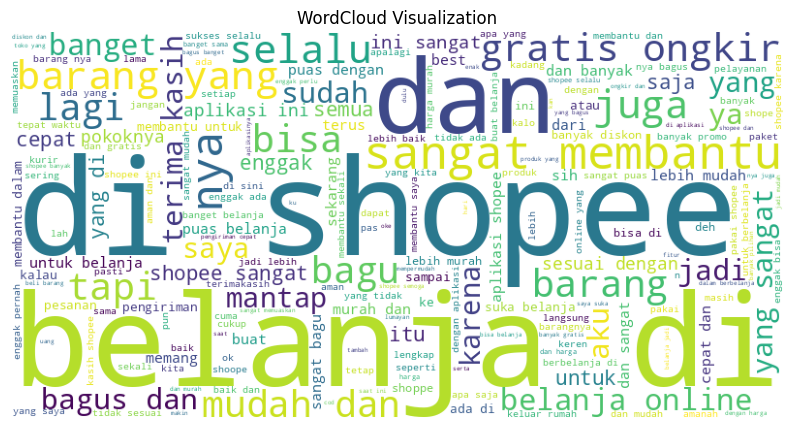

In [87]:
positif_content = df[df['label'] == 'Positif']['clean_content']

all_words = ''.join(positif_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

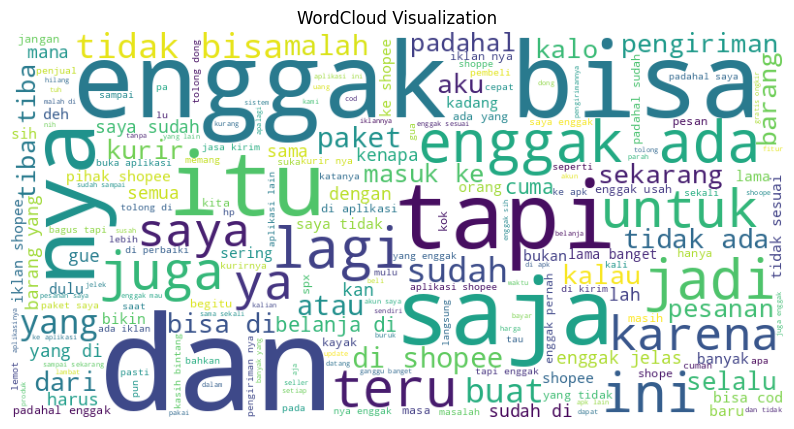

In [88]:
negatif_content = df[df['label'] == 'Negatif']['clean_content']

all_words = ''.join(negatif_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

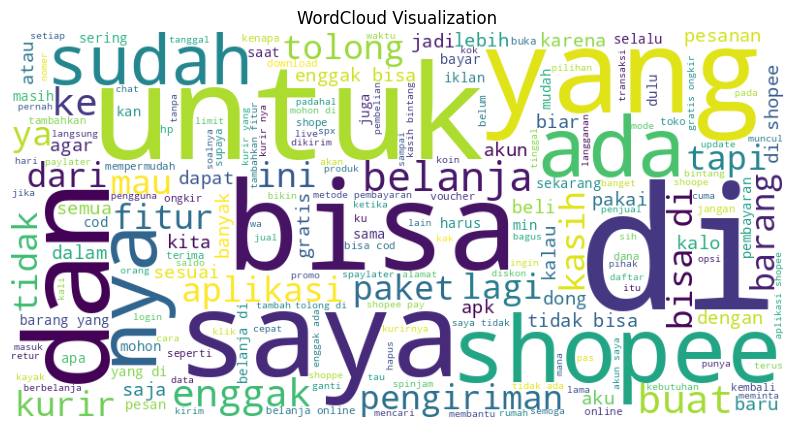

In [89]:
netral_content = df[df['label'] == 'Netral']['clean_content']

all_words = ''.join(netral_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

**Resample data berdasarkan class rata-rata**

In [90]:
df_negatif = df[df['label'] == 'Negatif']
df_netral = df[df['label'] == 'Netral']
df_positif = df[df['label'] == 'Positif']

n_samples = len(df_positif)

df_netral_upsampling = resample(df_netral, replace=True, n_samples=n_samples, random_state=42)
df_negatif_upsampling = resample(df_negatif, replace=True, n_samples=n_samples, random_state=42)

df_balanced = pd.concat([df_positif, df_negatif_upsampling, df_netral_upsampling])

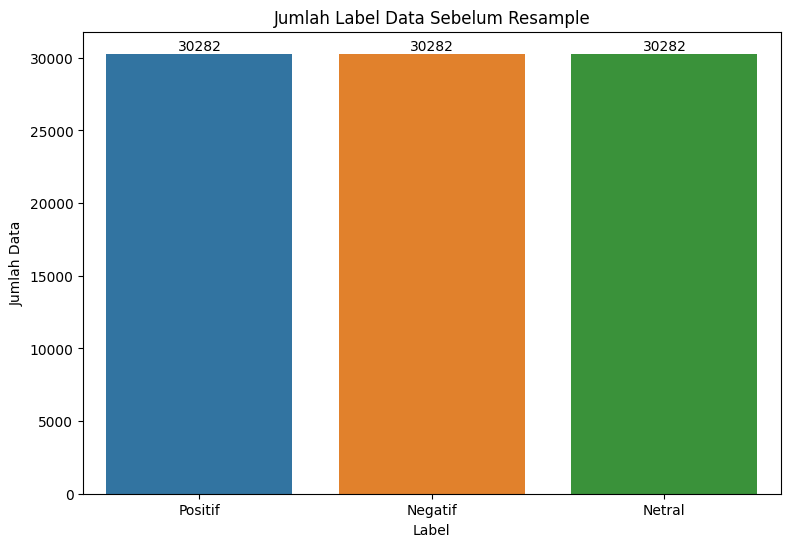

In [91]:
plt.figure(figsize=(9, 6))
sns.barplot(x=df_balanced['label'].value_counts().index, y=df_balanced['label'].value_counts().values, hue=df_balanced['label'].value_counts().index)
plt.title('Jumlah Label Data Sebelum Resample')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.show()

**Encoding label data**

In [92]:
le = LabelEncoder()
df_balanced['label_encoded'] = le.fit_transform(df_balanced['label'])

In [93]:
df_balanced.head()

,content,soft_clean_content,label,clean_content,label_encoded
1,Belanja di Shopee pelayanannya lebih meningkat...,Belanja di Shopee pelayanannya lebih meningkat...,Positif,belanja di shopee pelayanannya lebih meningkat...,2
6,terbaik👍,terbaik👍,Positif,terbaik,2
8,bagus banget,bagus banget,Positif,bagus banget,2
11,Top👍〽️✨️✨️,Top👍〽️✨️✨️,Positif,top,2
12,aplikasi belanja online terbaik yang pernah ak...,aplikasi belanja online terbaik yang pernah ak...,Positif,aplikasi belanja online terbaik yang pernah ak...,2


In [94]:
x = df_balanced['clean_content'].values

In [95]:
print(x)

['belanja di shopee pelayanannya lebih meningkat daripada waktuwaktu yang lalu'
 'terbaik' 'bagus banget' ...
 'teruntuk kurir meminta tolong ya kalau no wa costumer tidak aktif cobalah telepon biasa via pulsa terkadang wa tidak aktif jika tidak membuka wa tolong dipahami'
 'aplikasi babi' 'saya coba dulu kalau ok saya naik an bintang']


In [96]:
y = df_balanced['label_encoded'].values

In [97]:
print(y)
print(le.classes_)

[2 2 2 ... 1 1 1]
['Negatif' 'Netral' 'Positif']


In [98]:
y_onehot = to_categorical(y, num_classes=3)
y_onehot

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

**Splitting Data (Training-Testing-Validation) (80-20)**

In [99]:
X_train, X_test, y_train, y_test = train_test_split(x, y_onehot, test_size=0.20, random_state=42, stratify=y)

print(f"Jumlah Data Train : {len(X_train)}")
print(f"Jumlah Data Test  : {len(X_test)}")

Jumlah Data Train : 72676
Jumlah Data Test  : 18170


**Tokenization, sequence dan padding**

In [100]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lens = [len(s) for s in X_train_seq]
# max_len = int(np.percentile(lens, 95))
max_len = max(lens)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq,  maxlen=max_len, padding='pre', truncating='pre')

In [101]:
print("Ukuran Sequences : ", max_len)

Ukuran Sequences :  103


### **Model Word2Vec**

**Load model Word2Vec untuk transfer learning (input model)**

In [102]:
w2v_model = gensim.models.Word2Vec.load(fix_path).wv

In [103]:
EMBEDDING_DIM = 400

In [104]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

hits = 0
misses = 0

for word, i in word_index.items():
  if word in w2v_model:
    embedding_matrix[i] = w2v_model[word]
    hits += 1
  else:
    misses += 1

print(f"Berhasil: {hits}, Gagal (OOV): {misses}")

Berhasil: 10064, Gagal (OOV): 19565


**Balancing class menggunakan pembobotan**

In [105]:
# y_train_int = np.argmax(y_train, axis=1)

# class_weights_val = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_int),
#     y=y_train_int
# )
# class_weights_dict = dict(enumerate(class_weights_val))
# print(class_weights_dict)

### **Modelling**

In [106]:
akurasi_model = {}

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    accuracy = logs.get('accuracy')
    val_accuracy = logs.get('val_accuracy')

    if accuracy is not None and accuracy > 0.94 and val_accuracy > 0.94:
      print("\nAccuracy dan validation_accuracy > 94%. Menghentikan training.")
      self.model.stop_training = True

callback = myCallback()

**Model 1: BI-LSTM + Word Embedding**

In [107]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(LSTM(64, dropout=0.2, return_sequences=True))(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [108]:
model_1 = keras.Model(inputs=inputs, outputs=outputs)

In [109]:
model_1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_1 = model_1.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

Epoch 1/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.7463 - loss: 0.8448 - val_accuracy: 0.8797 - val_loss: 0.3370
Epoch 2/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.8981 - loss: 0.3064 - val_accuracy: 0.8965 - val_loss: 0.2955
Epoch 3/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9213 - loss: 0.2409 - val_accuracy: 0.9047 - val_loss: 0.2761
Epoch 4/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9354 - loss: 0.2019 - val_accuracy: 0.9132 - val_loss: 0.2630
Epoch 5/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9423 - loss: 0.1781 - val_accuracy: 0.9136 - val_loss: 0.2709
Epoch 6/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - accuracy: 0.9493 - loss: 0.1561 - val_accuracy: 0.9188 - val_loss: 0.2851
Epoch 7/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9542 - loss: 0.1408 - val_accuracy: 0.9234 - val_loss: 0.2730
Epoch 8/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step - accuracy: 0.9566 -

In [110]:
akurasi_model['BI-LSTM + Word Embedding'] = model_1.evaluate(X_test_pad, y_test)[1]

568/568 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9355 - loss: 0.3493


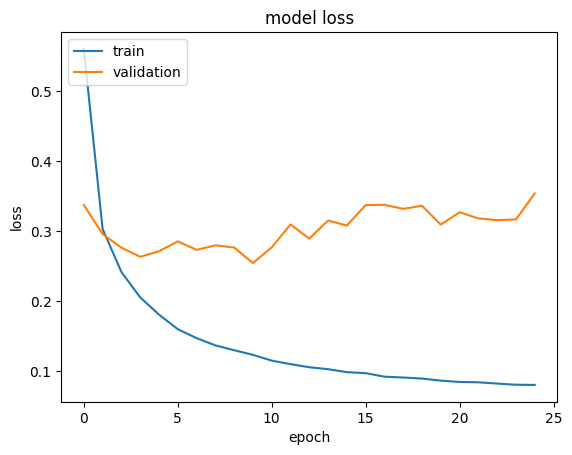

In [111]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [112]:
model_1.save('model_1.h5')

**Model 2: BI-LSTM + Word Embedding + Word2Vec Pre-Trained**

In [113]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)(inputs)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(LSTM(64, dropout=0.2, return_sequences=True))(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [114]:
model_2 = keras.Model(inputs=inputs, outputs=outputs)

In [115]:
model_2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_2 = model_2.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

Epoch 1/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.7213 - loss: 0.9110 - val_accuracy: 0.8063 - val_loss: 0.5044
Epoch 2/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.7972 - loss: 0.5387 - val_accuracy: 0.8313 - val_loss: 0.4564
Epoch 3/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8161 - loss: 0.4916 - val_accuracy: 0.8449 - val_loss: 0.4248
Epoch 4/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8299 - loss: 0.4669 - val_accuracy: 0.8431 - val_loss: 0.4222
Epoch 5/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8356 - loss: 0.4487 - val_accuracy: 0.8592 - val_loss: 0.3960
Epoch 6/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8500 - loss: 0.4210 - val_accuracy: 0.8661 - val_loss: 0.3820
Epoch 7/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8564 - loss: 0.4028 - val_accuracy: 0.8676 - val_loss: 0.3758
Epoch 8/25
2272/2272 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.8639 -

KeyboardInterrupt: 

In [ ]:
akurasi_model['BI-LSTM + Word Embedding + Word2Vec Pre-Trained'] = model_2.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_2.save('model_2.h5')

**Model 3: RNN + Word Embedding**

In [ ]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = SpatialDropout1D(0.3)(x)
x = SimpleRNN(64, dropout=0.2, return_sequences=True)(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [ ]:
model_3 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_3 = model_3.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

In [ ]:
akurasi_model['RNN + Word Embedding'] = model_3.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_3.save('model_3.h5')

**Model 4: RNN + Word Embedding + Word2Vec Pre-Trained**

In [ ]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)(inputs)
x = SpatialDropout1D(0.3)(x)
x = SimpleRNN(64, dropout=0.2, return_sequences=True)(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [ ]:
model_4 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_4 = model_4.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

In [ ]:
akurasi_model['RNN + Word Embedding + Word2Vec Pre-Trained'] = model_4.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_4.save('model_4.h5')

**Model 5: Logistic Regression + Word2Vec Pre-Trained (Average Weight)**

In [ ]:
def get_avg_vector(text_list, model, dim):
  vecs = []
  for text in text_list:
    words = text.split()
    vector_sum = np.zeros((dim,), dtype="float32")
    n_words = 0

    for w in words:
      if w in model:
        vector_sum = np.add(vector_sum, model[w])
        n_words += 1

    if n_words > 0:
      vector_sum = np.divide(vector_sum, n_words)

    vecs.append(vector_sum)
  return np.array(vecs)

In [ ]:
X_train_w2v = get_avg_vector(X_train, w2v_model, EMBEDDING_DIM)
X_test_w2v = get_avg_vector(X_test, w2v_model, EMBEDDING_DIM)
y_label_init = np.argmax(y_train, axis=1)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_w2v, y_label_init)

In [ ]:
y_pred_3 = clf.predict(X_test_w2v)
acc = accuracy_score(np.argmax(y_test, axis=1), y_pred_3)

print(f"Akurasi: {acc*100:.2f}%")
print(classification_report(np.argmax(y_test, axis=1), y_pred_3))

In [ ]:
akurasi_model['Logistic Regression + Word2Vec Pre-Trained (Average Weight)'] = acc

In [ ]:
with open('model_5.pkl', 'wb') as f:
  pickle.dump(clf, f)

### **Akumulasi Akurasi Model**

In [ ]:
count = 1
for key, value in akurasi_model.items():
  print(f"{count}. {key}: {value*100:.2f}%")
  count+=1

### **Test Prediksi Model**

In [ ]:
teks = "barang nya hancur banget, nyesel beli disini!!!"

In [ ]:
text_cleaned = cleaning_text(teks, normalization_dict)

text_seq = tokenizer.texts_to_sequences([text_cleaned])

text_padded = pad_sequences(text_seq, maxlen=max_len, padding='pre', truncating='pre')

In [ ]:
teks_2 = "barang nya bagus, pengiriman cepat"

In [ ]:
text_cleaned_2 = cleaning_text(teks_2, normalization_dict)

text_seq_2 = tokenizer.texts_to_sequences([text_cleaned_2])

text_padded_2 = pad_sequences(text_seq_2, maxlen=max_len, padding='pre', truncating='pre')

**Model 1**

In [ ]:
prediction_prob = model_1.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_1.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 2**

In [ ]:
prediction_prob = model_2.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_2.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 3**

In [ ]:
prediction_prob = model_3.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_3.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 4**

In [ ]:
prediction_prob = model_4.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_4.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 5**

In [ ]:
text_w2v = get_avg_vector([text_cleaned], w2v_model, EMBEDDING_DIM)
prediction_index_3 = clf.predict(text_w2v)[0]
final_label_3 = le.inverse_transform([prediction_index_3])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label_3}")

In [ ]:
text_w2v = get_avg_vector([text_cleaned_2], w2v_model, EMBEDDING_DIM)
prediction_index_3 = clf.predict(text_w2v)[0]
final_label_3 = le.inverse_transform([prediction_index_3])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label_3}")

**Load requirements.txt**

In [ ]:
# !pip freeze > requirements.txt